# MAT Thesis — Local CPU Inference Backend

Runs the FastAPI inference service (`colab_inference_api:app`) on **this Mac, on CPU** —
no Colab, no GPU, no Google Drive, no ngrok.

It is the local equivalent of `Inference_MAT_=_THESIS.ipynb`: it starts the same backend
and exposes the same `/infer` API, so the existing **Streamlit UI** can connect to it in
*remote* mode at `http://127.0.0.1:8000`.

**Keep this notebook running** — the kernel hosts the server. Stop it by interrupting/closing the kernel.

Pipeline served: `Input -> Mask -> Final Output`, with checkpoint switching
(`stage1` / `final` / `mat_baseline`).


## 1. Configure paths

Edit these two paths if your folders move. Defaults match this workspace.

In [2]:
import os, sys
from pathlib import Path

# The MAT code repo (must be on branch codex/phase3-thesis-ui-demo).
REPO_DIR = Path("/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/THESIS")
# Folder holding the .pkl checkpoints (current layout: INFERENCE-THEISIS/checkpoints/).
CKPT_DIR = Path("/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints")
# Fallback to the older flat layout (files directly in INFERENCE-THEISIS/).
if not (CKPT_DIR / "network-snapshot-000072.pkl").exists() and \
        (CKPT_DIR.parent / "network-snapshot-000072.pkl").exists():
    CKPT_DIR = CKPT_DIR.parent

assert REPO_DIR.exists(), f"THESIS repo not found at {REPO_DIR}"
assert CKPT_DIR.exists(), f"Checkpoint dir not found at {CKPT_DIR}"

# Make the repo importable and run from it (so demo_ui / generate_image / networks resolve).
sys.path.insert(0, str(REPO_DIR))
os.chdir(REPO_DIR)
print("Repo       :", REPO_DIR)
print("Checkpoints:", CKPT_DIR)


Repo       : /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/THESIS
Checkpoints: /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints


## 2. Device + CPU checkpoint-load shim

MAT `.pkl` files store CUDA tensors; on a CPU-only machine the nested unpickler must be told to map storages to CPU.

In [3]:
import torch

print("Torch:", torch.__version__,
      "| CUDA:", torch.cuda.is_available(),
      "| MPS:", torch.backends.mps.is_available())

# When no CUDA GPU is present, the backend already picks CPU automatically.
# But the checkpoints were saved on a GPU, so force CPU mapping during unpickling.
if not torch.cuda.is_available():
    import io as _io
    def _cpu_load_from_bytes(b):
        return torch.load(_io.BytesIO(b), map_location="cpu", weights_only=False)
    torch.storage._load_from_bytes = _cpu_load_from_bytes
    print("Applied CPU-load shim for GPU-saved .pkl checkpoints.")


Torch: 2.4.1 | CUDA: False | MPS: True
Applied CPU-load shim for GPU-saved .pkl checkpoints.


## 3. Import the backend and point it at local checkpoints

We override the Colab Google-Drive paths with the local `.pkl` files.

In [4]:
import colab_inference_api

colab_inference_api.CHECKPOINTS = {
    "stage1":       str(CKPT_DIR / "resume_phase1_from_finetune_plus_loss.pkl"),
    "final":        str(CKPT_DIR / "network-snapshot-000072.pkl"),
    "mat_baseline": str(CKPT_DIR / "Places_512_FullData.pkl"),
}

for name, p in colab_inference_api.CHECKPOINTS.items():
    print(f"{name:13s} {'OK     ' if Path(p).exists() else 'MISSING'} {p}")


stage1        OK      /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/resume_phase1_from_finetune_plus_loss.pkl
final         OK      /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/network-snapshot-000072.pkl
mat_baseline  OK      /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/Places_512_FullData.pkl


/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/.venv/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 4. Start the API server

Serves on `http://127.0.0.1:8000` in a background thread. Waits until `/health` responds.

In [5]:
import threading, time, requests
import nest_asyncio, uvicorn

nest_asyncio.apply()
HOST, PORT = "127.0.0.1", 8000

def _run():
    uvicorn.run(colab_inference_api.app, host=HOST, port=PORT, log_level="warning")

if not any(t.name == "mat-backend" for t in threading.enumerate()):
    threading.Thread(target=_run, name="mat-backend", daemon=True).start()

# Wait for readiness.
base = f"http://{HOST}:{PORT}"
for _ in range(60):
    try:
        if requests.get(base + "/health", timeout=2).ok:
            break
    except Exception:
        time.sleep(0.5)
print("Backend serving at", base)


Backend serving at http://127.0.0.1:8000


[load_generator_for_inference] Loading networks from: /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/Places_512_FullData.pkl
[load_generator_for_inference] Device: cpu
[load_generator_for_inference] Resolution: 512


/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/.venv/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[load_generator_for_inference] Loading networks from: /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/network-snapshot-000072.pkl
[load_generator_for_inference] Device: cpu
[load_generator_for_inference] Resolution: 512
[load_generator_for_inference] Loading networks from: /Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/resume_phase1_from_finetune_plus_loss.pkl
[load_generator_for_inference] Device: cpu
[load_generator_for_inference] Resolution: 512


## 5. Health check

In [6]:
import json, requests
r = requests.get(f"http://{HOST}:{PORT}/health", timeout=10)
print(r.status_code)
print(json.dumps(r.json(), indent=2))


200
{
  "status": "ok",
  "cuda_available": false,
  "gpu_name": null,
  "checkpoints": {
    "stage1": {
      "path": "/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/resume_phase1_from_finetune_plus_loss.pkl",
      "exists": true
    },
    "final": {
      "path": "/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/network-snapshot-000072.pkl",
      "exists": true
    },
    "mat_baseline": {
      "path": "/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/INFERENCE-THEISIS/checkpoints/Places_512_FullData.pkl",
      "exists": true
    }
  }
}


## 6. Test inference through the API

Sends a bundled 512×512 image+mask to `/infer`. First call loads the checkpoint (slow on CPU, ~20–40s); results are cached afterwards.

HTTP 200 | device: cpu | seconds: 5.982
Saved /tmp/api_out.png (512, 512) RGB


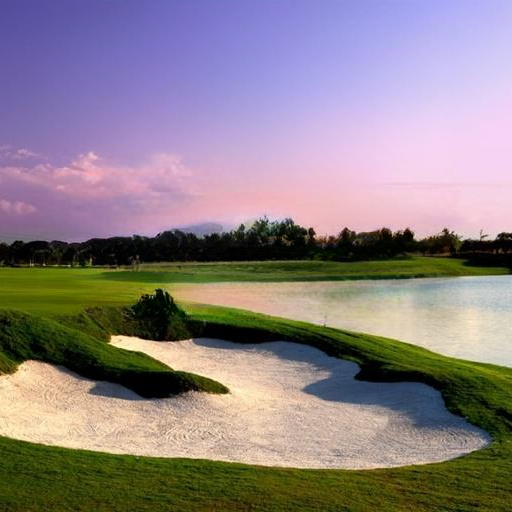

In [7]:
import base64, io, requests
from PIL import Image

img_path  = REPO_DIR / "test_sets/Places/images/test1.jpg"
mask_path = REPO_DIR / "test_sets/Places/masks/mask1.png"

with open(img_path, "rb") as fi, open(mask_path, "rb") as fm:
    resp = requests.post(
        f"http://{HOST}:{PORT}/infer",
        files={"image": ("img.jpg", fi, "image/jpeg"),
               "mask":  ("mask.png", fm, "image/png")},
        data={"checkpoint": "mat_baseline", "response_format": "json"},
        timeout=600,
    )

payload = resp.json()
print("HTTP", resp.status_code, "| device:", payload.get("device"),
      "| seconds:", payload.get("seconds"))

out = Image.open(io.BytesIO(base64.b64decode(payload["final_image_base64"])))
out.save("/tmp/api_out.png")
print("Saved /tmp/api_out.png", out.size, out.mode)
out


## 7. Connect the Streamlit UI

The backend above stays up while this notebook's kernel runs. In a **separate terminal**:

```bash
cd "/Users/thanganguyen/Documents/01-10 Repo/02 Thesis/02.01 ThuongNgo/THESIS"
COLAB_API_WITH_NGROK=http://127.0.0.1:8000 ./.venv/bin/streamlit run streamlit_app.py
```

Then in the UI:
- **Backend Mode** = `remote`
- **Remote endpoint** = `http://127.0.0.1:8000`

The UI sends the `checkpoint` field (`stage1` / `final` / `mat_baseline`) with each request,
so network switching works through this same backend.

> Note: inference runs on CPU, so each request takes ~20–40s (vs ~1s on the Colab T4).
